In [44]:
from __future__ import annotations

import warnings
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_samples, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
DATA_PATH = "movies_cleaned.csv"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.3f}".format)


The provided CSV is already cleaned from previous tasks.

In [45]:
movies_raw = pd.read_csv(DATA_PATH)
movies_raw.head()

,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,tagline,title,vote_average,vote_count,cast,crew,director
0,237000000.000,Action Adventure Fantasy Science Fiction,19995,culture clash future space war space colony so...,en,"In the 22nd century, a paraplegic Marine is di...",150.438,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087.000,162.000,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,Avatar,7.200,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,300000000.000,Adventure Fantasy Action,285,ocean drug abuse exotic island east india trad...,en,"Captain Barbossa, long believed to be dead, ha...",139.083,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000.000,169.000,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.900,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,245000000.000,Action Adventure Crime,206647,spy based on novel secret agent sequel mi6,en,A cryptic message from Bond’s past sends him o...,107.377,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609.000,148.000,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,Spectre,6.300,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,250000000.000,Action Crime Drama Thriller,49026,dc comics crime fighter terrorist secret ident...,en,Following the death of District Attorney Harve...,112.313,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099.000,165.000,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,The Dark Knight Rises,7.600,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,260000000.000,Action Adventure Science Fiction,49529,based on novel mars medallion space travel pri...,en,"John Carter is a war-weary, former military ca...",43.927,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100.000,132.000,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",John Carter,6.100,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


## Feature Engineering

Clustering has no target variable, so the selected features should describe movie similarity rather than predict success. I use two feature sets:

- Business set - budget, revenue, popularity, runtime, rating, vote count, and release year.
- Business + genre set - the same numeric features plus one-hot indicators for common genres.

In [46]:
KNOWN_GENRES = [
    "Action", "Adventure", "Animation", "Comedy", "Crime", "Documentary", "Drama",
    "Family", "Fantasy", "Foreign", "History", "Horror", "Music", "Mystery",
    "Romance", "Science Fiction", "TV Movie", "Thriller", "War", "Western",
]


def extract_genres(value: object) -> list[str]:
    text = "" if pd.isna(value) else str(value)
    return [genre for genre in KNOWN_GENRES if genre in text]


def prepare_movie_features(df: pd.DataFrame) -> pd.DataFrame:
    movies = df.copy()

    for col in ["budget", "revenue", "runtime", "popularity", "vote_average", "vote_count"]:
        movies[col] = pd.to_numeric(movies[col], errors="coerce")

    movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
    movies["release_year"] = movies["release_date"].dt.year

    movies["budget_log"] = np.log1p(movies["budget"].clip(lower=0))
    movies["revenue_log"] = np.log1p(movies["revenue"].clip(lower=0))
    movies["popularity_log"] = np.log1p(movies["popularity"].clip(lower=0))
    movies["vote_count_log"] = np.log1p(movies["vote_count"].clip(lower=0))
    movies["profit"] = movies["revenue"] - movies["budget"]

    movies["genre_list"] = movies["genres"].apply(extract_genres)
    for genre in KNOWN_GENRES:
        movies[f"genre_{genre.replace(' ', '_')}"] = movies["genre_list"].apply(lambda v, g=genre: int(g in v))

    movies = movies[movies["runtime"].fillna(0) > 0].copy()
    movies = movies[movies["vote_count"].fillna(0) > 0].copy()
    return movies.reset_index(drop=True)


movies = prepare_movie_features(movies_raw)
print(f"Rows after filtering: {len(movies):,}")
display(movies[["title", "budget", "revenue", "runtime", "popularity", "vote_average", "vote_count", "release_year", "genre_list"]].head())


Rows after filtering: 4,684


,title,budget,revenue,runtime,popularity,vote_average,vote_count,release_year,genre_list
0,Avatar,237000000.000,2787965087.000,162.000,150.438,7.200,11800,2009,"[Action, Adventure, Fantasy, Science Fiction]"
1,Pirates of the Caribbean: At World's End,300000000.000,961000000.000,169.000,139.083,6.900,4500,2007,"[Action, Adventure, Fantasy]"
2,Spectre,245000000.000,880674609.000,148.000,107.377,6.300,4466,2015,"[Action, Adventure, Crime]"
3,The Dark Knight Rises,250000000.000,1084939099.000,165.000,112.313,7.600,9106,2012,"[Action, Crime, Drama, Thriller]"
4,John Carter,260000000.000,284139100.000,132.000,43.927,6.100,2124,2012,"[Action, Adventure, Science Fiction]"


Drama              2264
Comedy             1700
Thriller           1246
Action             1146
Romance             884
Adventure           789
Crime               688
Science Fiction     528
Horror              504
Family              502
Fantasy             418
Mystery             343
Name: count, dtype: int64

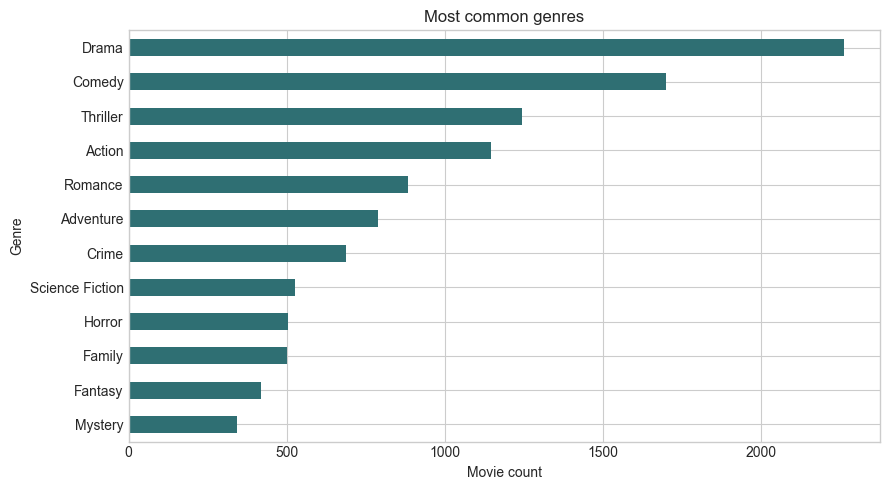

In [47]:
genre_counts = pd.Series([genre for values in movies["genre_list"] for genre in values]).value_counts()
display(genre_counts.head(12))

genre_counts.head(12).sort_values().plot(kind="barh", figsize=(9, 5), color="#2f6f73")
plt.title("Most common genres")
plt.xlabel("Movie count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


## Build Feature Sets

In [48]:
numeric_features = [
    "budget_log",
    "revenue_log",
    "popularity_log",
    "runtime",
    "vote_average",
    "vote_count_log",
    "release_year",
]

top_genres = genre_counts.head(10).index.tolist()
genre_features = [f"genre_{genre.replace(' ', '_')}" for genre in top_genres]

feature_sets = {
    "business_numeric": numeric_features,
    "business_plus_genre": numeric_features + genre_features,
}


def make_scaled_matrix(df: pd.DataFrame, columns: list[str]) -> tuple[np.ndarray, pd.DataFrame, StandardScaler]:
    feature_frame = df[columns].replace([np.inf, -np.inf], np.nan).copy()
    feature_frame = feature_frame.fillna(feature_frame.median(numeric_only=True))
    scaler = StandardScaler()
    matrix = scaler.fit_transform(feature_frame)
    return matrix, feature_frame, scaler


X = {}
feature_frames = {}
scalers = {}
for name, columns in feature_sets.items():
    X[name], feature_frames[name], scalers[name] = make_scaled_matrix(movies, columns)
    print(f"{name}: {X[name].shape[0]:,} rows x {X[name].shape[1]} features")

display(pd.DataFrame({"feature_set": feature_sets.keys(), "features": [", ".join(v) for v in feature_sets.values()]}))


business_numeric: 4,684 rows x 7 features
business_plus_genre: 4,684 rows x 17 features


,feature_set,features
0,business_numeric,"budget_log, revenue_log, popularity_log, runti..."
1,business_plus_genre,"budget_log, revenue_log, popularity_log, runti..."


## K-Means From Scratch

In [49]:
@dataclass
class ScratchKMeans:
    k = 3
    max_iter = 300
    tol = 1e-4
    random_state = None

    def _init_centroids(self, matrix):
        rng = np.random.default_rng(self.random_state)
        n_samples = matrix.shape[0]
        centroids = np.empty((self.k, matrix.shape[1]), dtype=float)

        first_idx = rng.integers(n_samples)
        centroids[0] = matrix[first_idx]
        closest_dist_sq = np.sum((matrix - centroids[0]) ** 2, axis=1)

        for centroid_idx in range(1, self.k):
            total = closest_dist_sq.sum()
            probabilities = np.full(n_samples, 1 / n_samples) if total == 0 else closest_dist_sq / total
            chosen_idx = rng.choice(n_samples, p=probabilities)
            centroids[centroid_idx] = matrix[chosen_idx]
            new_dist_sq = np.sum((matrix - centroids[centroid_idx]) ** 2, axis=1)
            closest_dist_sq = np.minimum(closest_dist_sq, new_dist_sq)

        return centroids

    @staticmethod
    def _distances(matrix, centroids):                                                               
      n_movies = matrix.shape[0]
      k = centroids.shape[0]                                                                       
      distances = np.zeros((n_movies, k))
                                                                                                   
      for i in range(n_movies):
          for j in range(k):
              distances[i, j] = np.sqrt(np.sum((matrix[i] - centroids[j]) ** 2))
                                                                                                   
      return distances
    
    def fit(self, matrix):
        matrix = np.asarray(matrix, dtype=float)
        centroids = self._init_centroids(matrix)

        for iteration in range(1, self.max_iter + 1):
            distances = self._distances(matrix, centroids)
            # atstumai nuo visu tasku iki centroidu
            labels = distances.argmin(axis=1)
            # kiekvieno tasko atstumas iki centroido (tustiem clusteriam handle, **2 inercijai kur irgi kvadratai skaiciavimuose)
            min_dist_sq = (distances[np.arange(len(matrix)), labels]) ** 2

            # senu centroidu kopija - kiekvienam klusteriui pasirenka visus jo filmus 
            new_centroids = centroids.copy()
            for cluster_id in range(self.k):
                members = matrix[labels == cluster_id]
                # jei centroidas neturi tasku, perkelti ji i tolimiausia taska
                if len(members) == 0:
                    new_centroids[cluster_id] = matrix[min_dist_sq.argmax()]
                else:
                    new_centroids[cluster_id] = members.mean(axis=0)

            # didziausias atstumas, per kiek pajudejo kazkuris centroidas
            shift = np.sqrt(((new_centroids - centroids) ** 2).sum(axis=1)).max()
            centroids = new_centroids
            if shift <= self.tol:
                break

        final_distances = self._distances(matrix, centroids)
        self.labels_ = final_distances.argmin(axis=1)
        self.cluster_centers_ = centroids
        self.inertia_ = float(((matrix - centroids[self.labels_]) ** 2).sum())
        self.n_iter_ = iteration
        return self

    def predict(self, matrix):
        return self._distances(np.asarray(matrix, dtype=float), self.cluster_centers_).argmin(axis=1)


## Scratch K-Means vs scikit-learn

Exact labels can differ because cluster IDs are arbitrary and initialization may differ. The comparison therefore uses inertia and Adjusted Rand Index (ARI), which is invariant to label renaming.

In [50]:
scratch_models = {}
sklearn_models = {}
rows = []

for k in range(2, 6):
    scratch = ScratchKMeans()
    scratch.k = k
    scratch.random_state = RANDOM_STATE
    scratch.fit(X["business_numeric"])
    scratch_models[k] = scratch

    sklearn_km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X["business_numeric"])
    sklearn_models[k] = sklearn_km

    ari = adjusted_rand_score(scratch.labels_, sklearn_km.labels_)
    rows.append({
        "k": k,
        "scratch_inertia": scratch.inertia_,
        "sklearn_inertia": sklearn_km.inertia_,
        "scratch_iters": scratch.n_iter_,
        "sklearn_iters": sklearn_km.n_iter_,
        "scratch_silhouette": silhouette_score(X["business_numeric"], scratch.labels_),
        "sklearn_silhouette": silhouette_score(X["business_numeric"], sklearn_km.labels_),
        "ari": ari,
    })

comparison = pd.DataFrame(rows)
display(comparison)


,k,scratch_inertia,sklearn_inertia,scratch_iters,sklearn_iters,scratch_silhouette,sklearn_silhouette,ari
0,2,24502.991,24503.018,17,8,0.244,0.244,0.998
1,3,21472.276,21472.116,34,15,0.251,0.253,0.945
2,4,19396.456,19275.814,35,15,0.170,0.250,0.338
3,5,17344.957,17343.157,37,23,0.180,0.181,0.931


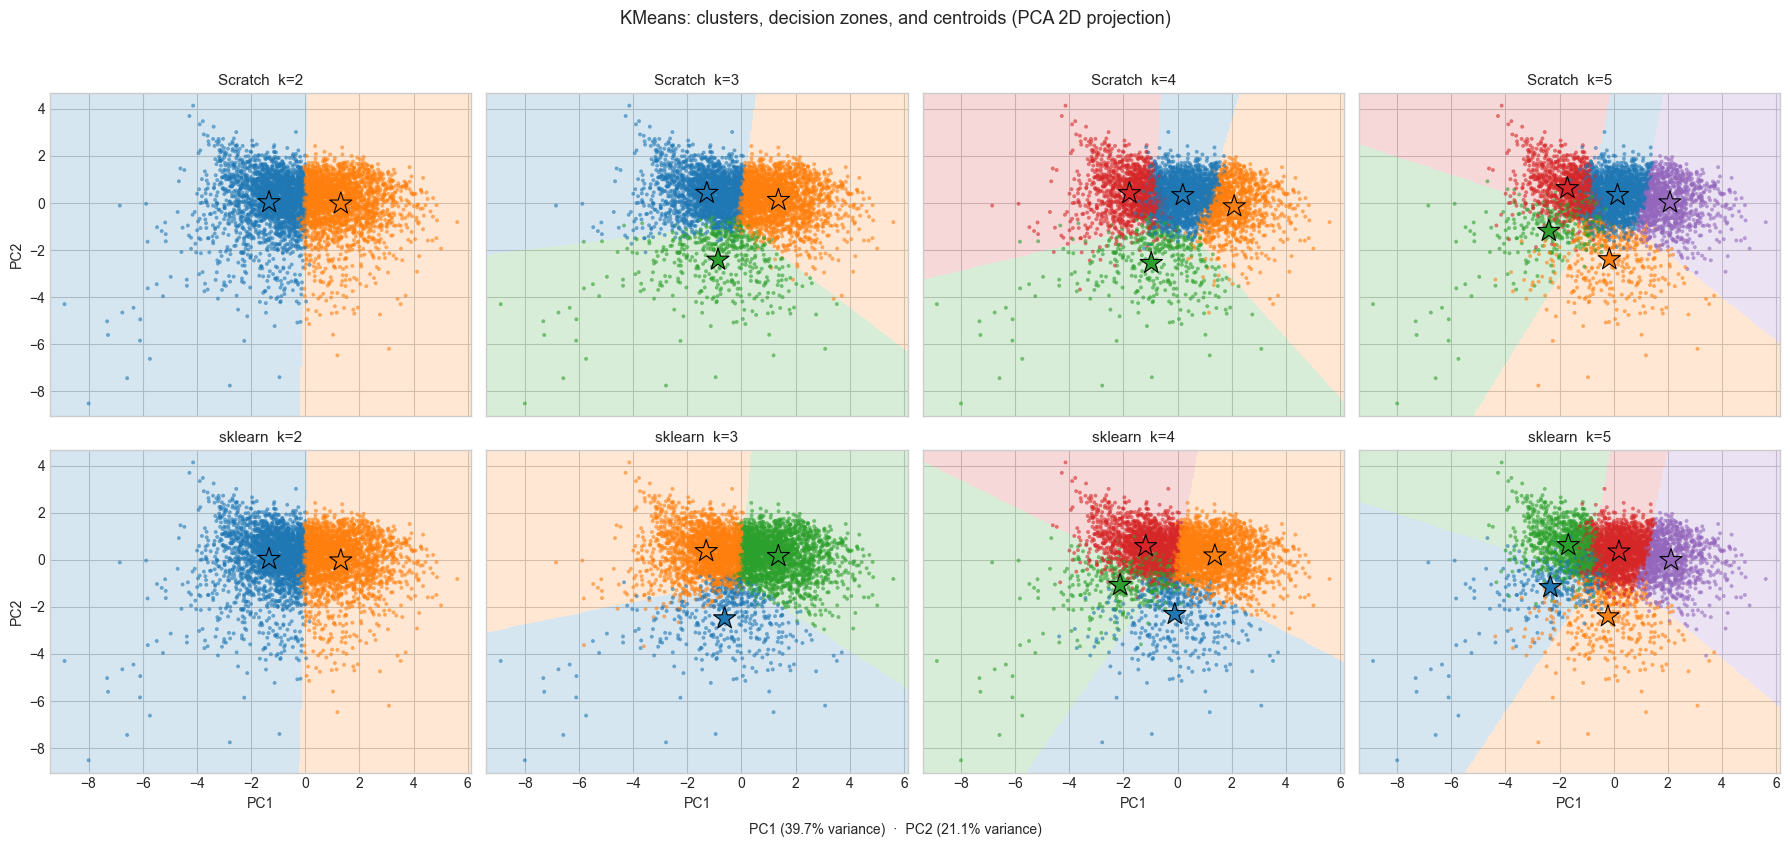

In [51]:
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
coords_2d = pca_vis.fit_transform(X["business_numeric"])

pad = 0.5
x_min, x_max = coords_2d[:, 0].min() - pad, coords_2d[:, 0].max() + pad
y_min, y_max = coords_2d[:, 1].min() - pad, coords_2d[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
mesh_pts = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)

for col, k in enumerate(range(2, 6)):
    for row, (name, model_dict) in enumerate([("Scratch", scratch_models), ("sklearn", sklearn_models)]):
        ax = axes[row, col]
        model = model_dict[k]
        centers_2d = pca_vis.transform(model.cluster_centers_)

        # Decision zones: colour each mesh point by its nearest centroid (in 2D PCA space)
        dists = np.sqrt(((mesh_pts[:, None] - centers_2d[None]) ** 2).sum(axis=2))
        zone = dists.argmin(axis=1).reshape(xx.shape)
        ax.pcolormesh(xx, yy, zone, cmap="tab10", alpha=0.18, vmin=0, vmax=9, shading="auto")

        # Data points coloured by cluster
        ax.scatter(coords_2d[:, 0], coords_2d[:, 1], c=model.labels_,
                   cmap="tab10", s=8, alpha=0.6, vmin=0, vmax=9, linewidths=0)

        # Centroids as stars
        ax.scatter(centers_2d[:, 0], centers_2d[:, 1], c=np.arange(k),
                   cmap="tab10", s=280, marker="*", edgecolors="black",
                   linewidths=0.8, zorder=5, vmin=0, vmax=9)

        ax.set_title(f"{name}  k={k}", fontsize=11)
        if col == 0:
            ax.set_ylabel("PC2")
        if row == 1:
            ax.set_xlabel("PC1")

v1, v2 = pca_vis.explained_variance_ratio_
fig.text(0.5, -0.01, f"PC1 ({v1:.1%} variance)  ·  PC2 ({v2:.1%} variance)", ha="center", fontsize=10)
plt.suptitle("KMeans: clusters, decision zones, and centroids (PCA 2D projection)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## Select proper k

,k,inertia,silhouette
0,2,24503.018,0.244
1,3,21472.116,0.253
2,4,19275.814,0.250
3,5,17343.157,0.181
4,6,16057.802,0.191
5,7,14898.774,0.179
6,8,13940.783,0.170
7,9,13178.728,0.169
8,10,12511.112,0.169


Selected k from highest silhouette on business_numeric features: 3


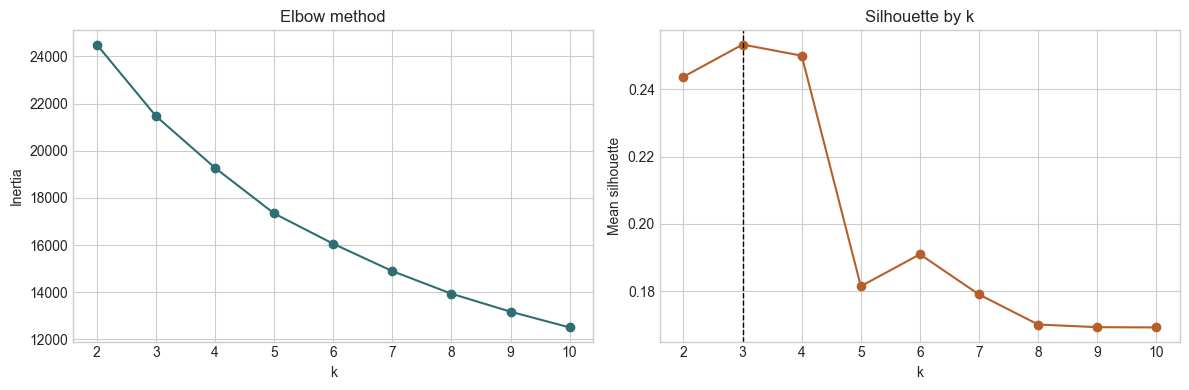

In [52]:
k_values = range(2, 11)
k_rows = []

for k in k_values:
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X["business_numeric"])
    k_rows.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X["business_numeric"], labels),
        }
    )

k_selection = pd.DataFrame(k_rows)
selected_k = int(k_selection.loc[k_selection["silhouette"].idxmax(), "k"])

display(k_selection)
print(f"Selected k from highest silhouette on business_numeric features: {selected_k}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_selection["k"], k_selection["inertia"], marker="o", color="#2f6f73")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_selection["k"], k_selection["silhouette"], marker="o", color="#b65f2a")
axes[1].axvline(selected_k, linestyle="--", color="black", linewidth=1)
axes[1].set_title("Silhouette by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Mean silhouette")

plt.tight_layout()
plt.show()


## DBSCAN

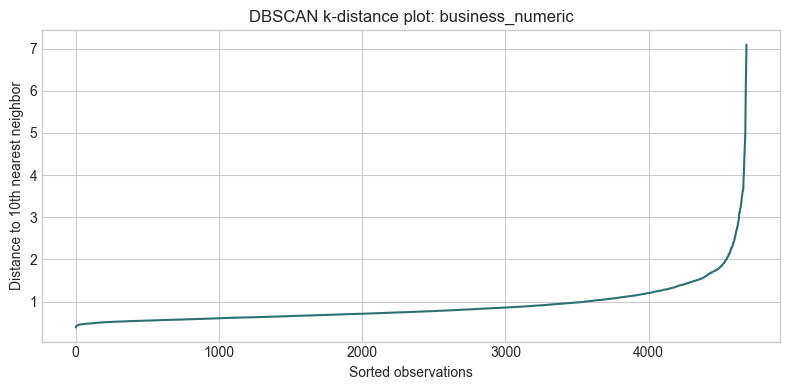

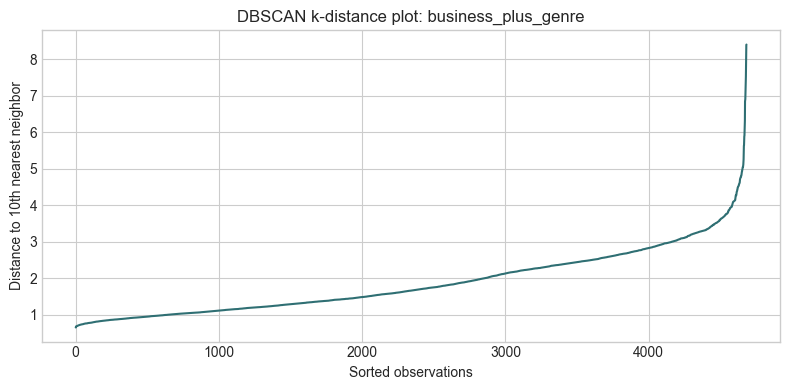

In [53]:
MIN_SAMPLES = 10


def plot_k_distance(matrix: np.ndarray, title: str, min_samples: int = MIN_SAMPLES) -> np.ndarray:
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    distances, _ = neighbors.fit(matrix).kneighbors(matrix)
    kth_distances = np.sort(distances[:, -1])

    plt.figure(figsize=(8, 4))
    plt.plot(kth_distances, color="#2f6f73")
    plt.title(title)
    plt.xlabel("Sorted observations")
    plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
    plt.tight_layout()
    plt.show()
    return kth_distances


k_distances = {name: plot_k_distance(matrix, f"DBSCAN k-distance plot: {name}") for name, matrix in X.items()}


In [ ]:
def dbscan_summary(matrix, eps, min_samples = MIN_SAMPLES):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(matrix)
    non_noise = labels != -1
    cluster_count = len(set(labels[non_noise]))
    noise_share = 1 - non_noise.mean()

    if cluster_count >= 2 and non_noise.sum() > cluster_count:
        score = silhouette_score(matrix[non_noise], labels[non_noise])
    else:
        score = np.nan

    return {
        "eps": eps,
        "clusters": cluster_count,
        "noise_share": noise_share,
        "silhouette_without_noise": score,
    }


def choose_dbscan(matrix, kth_distances):
    quantiles = [0.80, 0.85, 0.90, 0.93, 0.95, 0.97, 0.98]
    eps_candidates = sorted(set(np.quantile(kth_distances, quantiles).round(3)))
    report = pd.DataFrame([dbscan_summary(matrix, eps) for eps in eps_candidates])

    valid = report[report["silhouette_without_noise"].notna()].copy()
    if valid.empty:
        chosen_eps = float(report.iloc[len(report) // 2]["eps"])
    else:
        # Prefer meaningful separation but avoid solutions that label almost everything as noise.
        valid["selection_score"] = valid["silhouette_without_noise"] - 0.25 * valid["noise_share"]
        chosen_eps = float(valid.loc[valid["selection_score"].idxmax(), "eps"])

    return DBSCAN(eps=chosen_eps, min_samples=MIN_SAMPLES).fit(matrix), report


dbscan_models = {}
dbscan_reports = {}
for name, matrix in X.items():
    dbscan_models[name], dbscan_reports[name] = choose_dbscan(matrix, k_distances[name])
    print(f"DBSCAN candidates for {name}")
    display(dbscan_reports[name])
    print(f"Chosen eps: {dbscan_models[name].eps}\n")


DBSCAN candidates for business_numeric


,eps,clusters,noise_share,silhouette_without_noise
0,1.071,1,0.116,NaN
1,1.188,1,0.084,NaN
2,1.381,1,0.048,NaN
3,1.531,1,0.034,NaN
4,1.708,1,0.023,NaN
5,1.996,1,0.017,NaN
6,2.389,1,0.011,NaN


Chosen eps: 1.531

DBSCAN candidates for business_plus_genre


,eps,clusters,noise_share,silhouette_without_noise
0,2.604,14,0.097,0.142
1,2.807,9,0.062,0.152
2,3.065,6,0.034,0.150
3,3.273,1,0.024,NaN
4,3.459,1,0.018,NaN
5,3.763,1,0.010,NaN
6,4.088,1,0.007,NaN


Chosen eps: 3.065



## 9. Train Four Clustering Models

This satisfies the requirement to apply two algorithms to two feature sets:

- KMeans on business/numeric features;
- KMeans on business + genre features;
- DBSCAN on business/numeric features;
- DBSCAN on business + genre features.

In [55]:
def evaluate_labels(matrix: np.ndarray, labels: np.ndarray) -> dict[str, float]:
    labels = np.asarray(labels)
    non_noise = labels != -1
    cluster_count = len(set(labels[non_noise]))
    noise_share = 1 - non_noise.mean()

    if cluster_count >= 2 and non_noise.sum() > cluster_count:
        silhouette = silhouette_score(matrix[non_noise], labels[non_noise])
    else:
        silhouette = np.nan

    return {
        "clusters_without_noise": cluster_count,
        "noise_share": noise_share,
        "silhouette_without_noise": silhouette,
    }


trained_models = {}
model_rows = []

for feature_set_name, matrix in X.items():
    kmeans = KMeans(n_clusters=selected_k, n_init=20, random_state=RANDOM_STATE).fit(matrix)
    trained_models[("KMeans", feature_set_name)] = kmeans
    model_rows.append(
        {
            "algorithm": "KMeans",
            "feature_set": feature_set_name,
            "main_parameter": f"k={selected_k}",
            "inertia": kmeans.inertia_,
            **evaluate_labels(matrix, kmeans.labels_),
        }
    )

    dbscan = dbscan_models[feature_set_name]
    trained_models[("DBSCAN", feature_set_name)] = dbscan
    model_rows.append(
        {
            "algorithm": "DBSCAN",
            "feature_set": feature_set_name,
            "main_parameter": f"eps={dbscan.eps}, min_samples={MIN_SAMPLES}",
            "inertia": np.nan,
            **evaluate_labels(matrix, dbscan.labels_),
        }
    )

model_comparison = pd.DataFrame(model_rows)
display(model_comparison.sort_values("silhouette_without_noise", ascending=False))


,algorithm,feature_set,main_parameter,inertia,clusters_without_noise,noise_share,silhouette_without_noise
0,KMeans,business_numeric,k=3,21472.116,3,0.000,0.253
3,DBSCAN,business_plus_genre,"eps=3.065, min_samples=10",NaN,6,0.034,0.150
2,KMeans,business_plus_genre,k=3,64849.540,3,0.000,0.140
1,DBSCAN,business_numeric,"eps=1.531, min_samples=10",NaN,1,0.034,NaN


## 10. Evaluate and Visualize One Result Set

For detailed interpretation I use KMeans on the `business_plus_genre` feature set. This result is easier to explain than DBSCAN because every movie belongs to a cluster and KMeans provides centroids.

Chosen result: KMeans on business_plus_genre
Mean silhouette: 0.140


cluster
0     503
1    1814
2    2367
Name: movies_in_cluster, dtype: int64

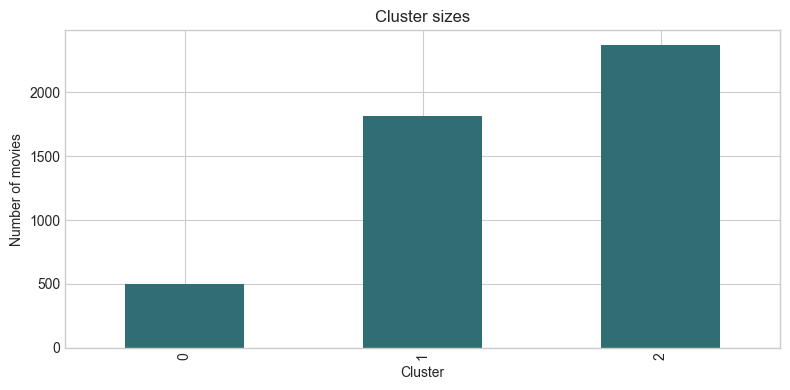

In [56]:
chosen_algorithm = "KMeans"
chosen_feature_set = "business_plus_genre"
chosen_matrix = X[chosen_feature_set]
chosen_model = trained_models[(chosen_algorithm, chosen_feature_set)]
chosen_labels = chosen_model.labels_

clustered_movies = movies.copy()
clustered_movies["cluster"] = chosen_labels

print(f"Chosen result: {chosen_algorithm} on {chosen_feature_set}")
print(f"Mean silhouette: {silhouette_score(chosen_matrix, chosen_labels):.3f}")
display(clustered_movies["cluster"].value_counts().sort_index().rename("movies_in_cluster"))

clustered_movies["cluster"].value_counts().sort_index().plot(kind="bar", figsize=(8, 4), color="#2f6f73")
plt.title("Cluster sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()


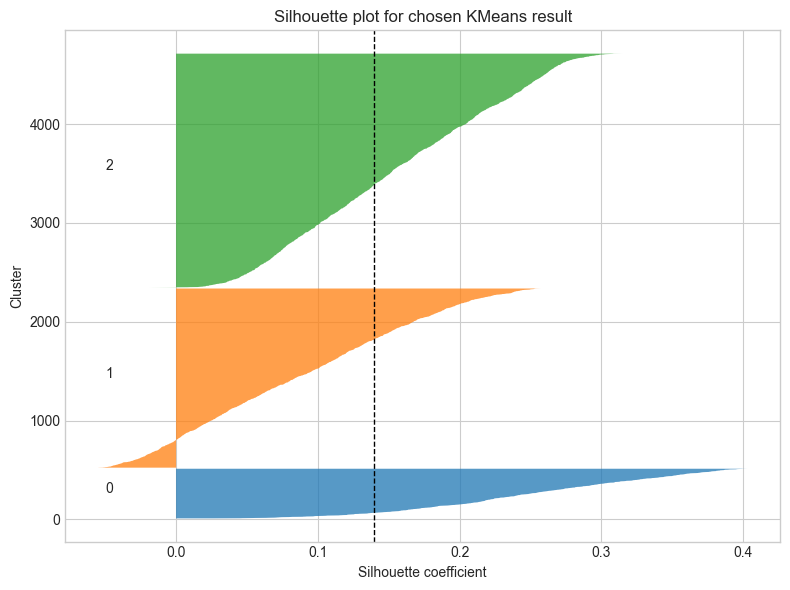

In [57]:
sample_values = silhouette_samples(chosen_matrix, chosen_labels)
y_lower = 10
plt.figure(figsize=(8, 6))

for cluster_id in sorted(np.unique(chosen_labels)):
    cluster_values = np.sort(sample_values[chosen_labels == cluster_id])
    y_upper = y_lower + len(cluster_values)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values, alpha=0.75)
    plt.text(-0.05, y_lower + 0.5 * len(cluster_values), str(cluster_id))
    y_lower = y_upper + 10

plt.axvline(sample_values.mean(), color="black", linestyle="--", linewidth=1)
plt.title("Silhouette plot for chosen KMeans result")
plt.xlabel("Silhouette coefficient")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


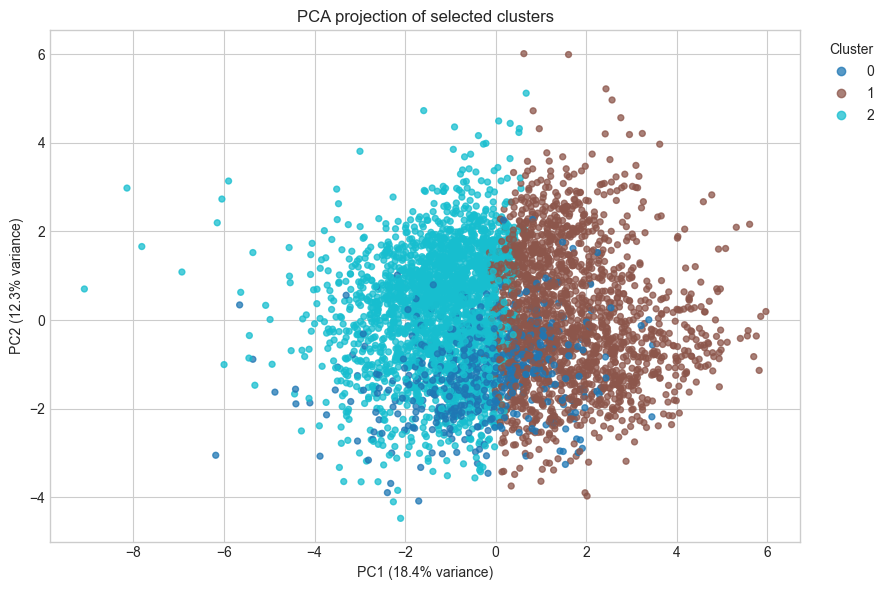

In [58]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(chosen_matrix)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=chosen_labels, cmap="tab10", s=18, alpha=0.75)
plt.title("PCA projection of selected clusters")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(*scatter.legend_elements(), title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 11. Cluster Interpretation

In [59]:
profile_columns = [
    "budget",
    "revenue",
    "profit",
    "popularity",
    "runtime",
    "vote_average",
    "vote_count",
    "release_year",
]

cluster_profile = clustered_movies.groupby("cluster").agg(
    movies=("id", "count"),
    median_budget=("budget", "median"),
    median_revenue=("revenue", "median"),
    median_profit=("profit", "median"),
    median_popularity=("popularity", "median"),
    median_runtime=("runtime", "median"),
    mean_rating=("vote_average", "mean"),
    median_votes=("vote_count", "median"),
    median_release_year=("release_year", "median"),
).sort_index()

display(cluster_profile)


,movies,median_budget,median_revenue,median_profit,median_popularity,median_runtime,mean_rating,median_votes,median_release_year
cluster,,,,,,,,,
0,503,11000000.000,40423945.000,25419521.000,12.982,95.000,5.717,272.000,2006.000
1,1814,45000000.000,116719734.000,68617009.000,31.598,111.000,6.443,875.000,2006.000
2,2367,12000000.000,16995951.000,3929123.000,6.138,101.000,6.075,73.000,2004.000


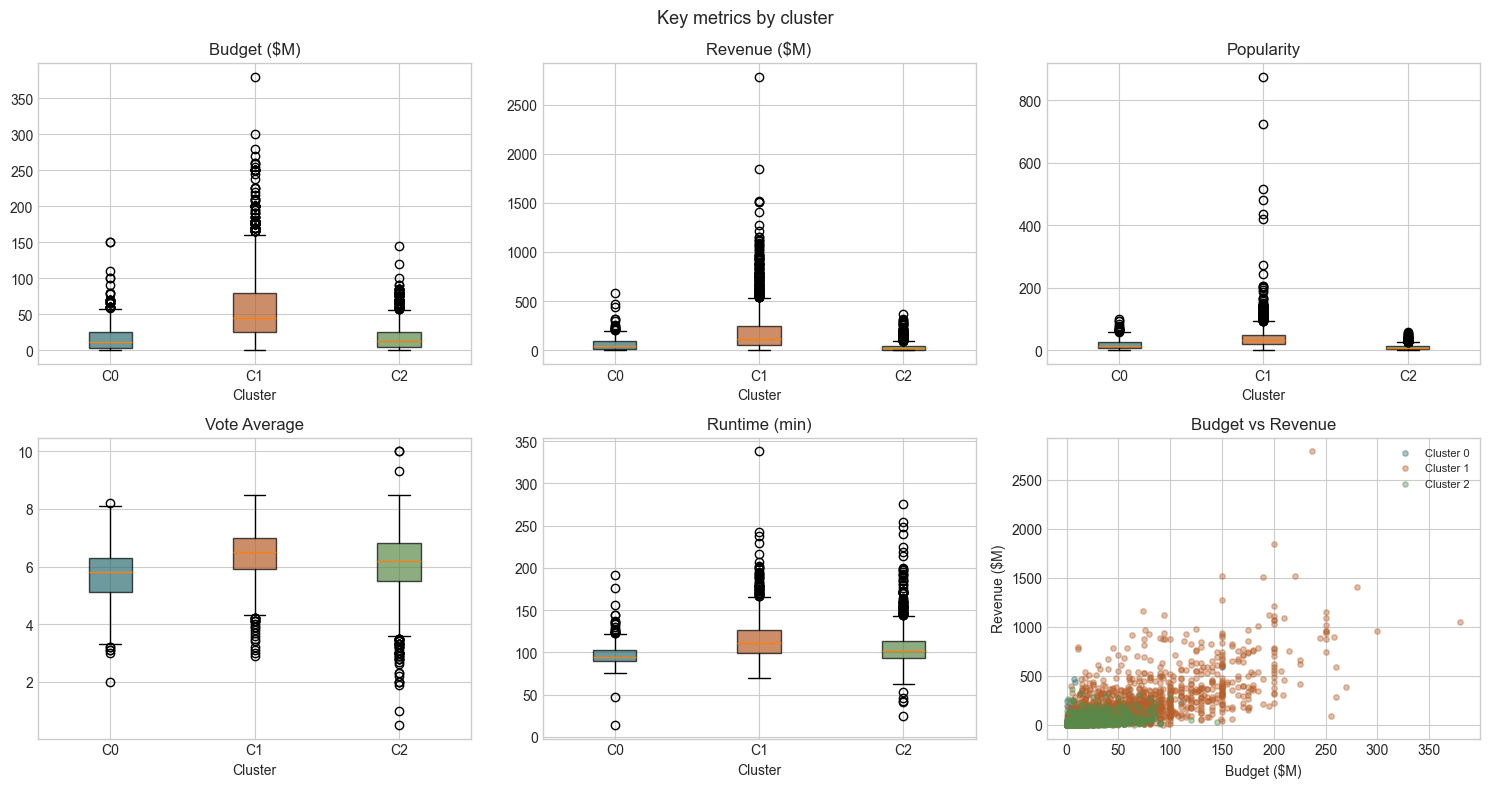

In [60]:
cluster_ids = sorted(clustered_movies["cluster"].unique())
palette = ["#2f6f73", "#b65f2a", "#5a8a4a"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

box_specs = [
    ("budget", "Budget ($M)", 1e6),
    ("revenue", "Revenue ($M)", 1e6),
    ("popularity", "Popularity", 1),
    ("vote_average", "Vote Average", 1),
    ("runtime", "Runtime (min)", 1),
]

for ax, (col, label, scale) in zip(axes, box_specs):
    data = [clustered_movies.loc[clustered_movies["cluster"] == c, col].dropna().values / scale
            for c in cluster_ids]
    bp = ax.boxplot(data, patch_artist=True, labels=[f"C{c}" for c in cluster_ids])
    for patch, color in zip(bp["boxes"], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(label)
    ax.set_xlabel("Cluster")

# Scatter: budget vs revenue by cluster
ax = axes[5]
for c, color in zip(cluster_ids, palette):
    mask = clustered_movies["cluster"] == c
    ax.scatter(
        clustered_movies.loc[mask, "budget"] / 1e6,
        clustered_movies.loc[mask, "revenue"] / 1e6,
        c=color, alpha=0.4, s=15, label=f"Cluster {c}",
    )
ax.set_xlabel("Budget ($M)")
ax.set_ylabel("Revenue ($M)")
ax.set_title("Budget vs Revenue")
ax.legend(fontsize=8)

plt.suptitle("Key metrics by cluster", fontsize=13)
plt.tight_layout()
plt.show()


,genre_Drama,genre_Comedy,genre_Thriller,genre_Action,genre_Romance,genre_Adventure,genre_Crime,genre_Science_Fiction,genre_Horror,genre_Family
cluster,,,,,,,,,,
0,0.163,0.147,0.561,0.149,0.028,0.040,0.072,0.187,0.998,0.002
1,0.380,0.272,0.376,0.452,0.075,0.352,0.240,0.187,0.001,0.154
2,0.631,0.478,0.119,0.106,0.310,0.055,0.091,0.040,0.000,0.093


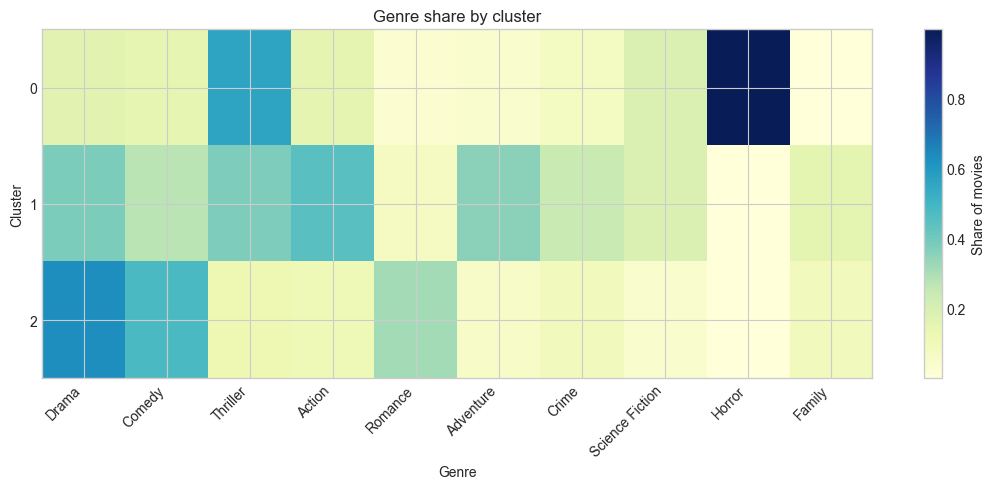

In [61]:
genre_share_by_cluster = clustered_movies.groupby("cluster")[genre_features].mean()
display(genre_share_by_cluster)

fig, ax = plt.subplots(figsize=(11, 5))
image = ax.imshow(genre_share_by_cluster, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(genre_features)))
ax.set_xticklabels([col.replace("genre_", "").replace("_", " ") for col in genre_features], rotation=45, ha="right")
ax.set_yticks(range(len(genre_share_by_cluster.index)))
ax.set_yticklabels(genre_share_by_cluster.index)
ax.set_title("Genre share by cluster")
ax.set_xlabel("Genre")
ax.set_ylabel("Cluster")
fig.colorbar(image, ax=ax, label="Share of movies")
plt.tight_layout()
plt.show()


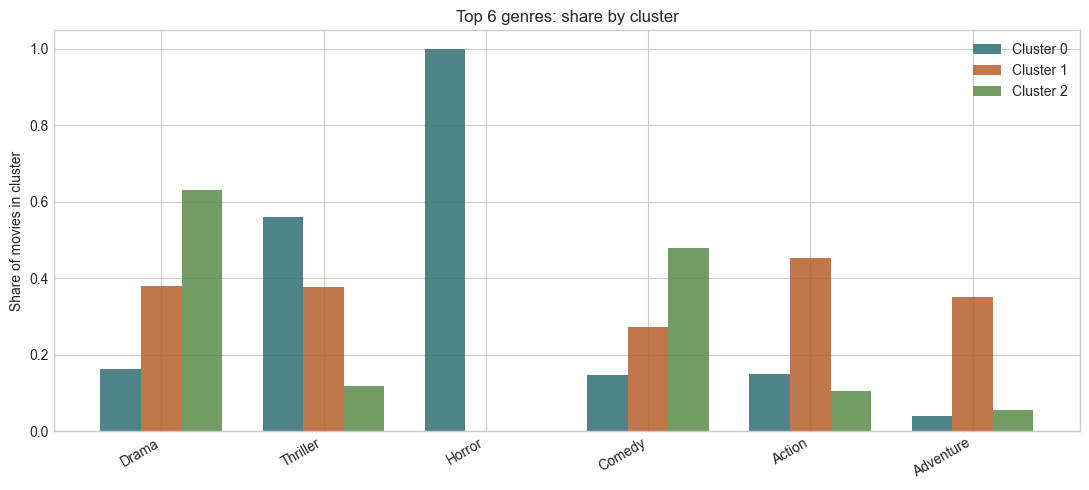

In [62]:
top_n = 6
top_cols = genre_share_by_cluster.mean().nlargest(top_n).index.tolist()
top_labels = [c.replace("genre_", "").replace("_", " ") for c in top_cols]

x = np.arange(len(top_labels))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
for i, (c, color) in enumerate(zip(cluster_ids, palette)):
    ax.bar(x + i * width, genre_share_by_cluster.loc[c, top_cols].values, width,
           label=f"Cluster {c}", color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(top_labels, rotation=30, ha="right")
ax.set_ylabel("Share of movies in cluster")
ax.set_title(f"Top {top_n} genres: share by cluster")
ax.legend()
plt.tight_layout()
plt.show()


In [63]:
def representative_movies(df: pd.DataFrame, cluster_id: int, n: int = 5) -> pd.DataFrame:
    columns = ["title", "release_year", "genres", "budget", "revenue", "popularity", "vote_average", "vote_count"]
    cluster_df = df[df["cluster"] == cluster_id].copy()
    return cluster_df.sort_values(["popularity", "vote_count"], ascending=False)[columns].head(n)


for cluster_id in sorted(clustered_movies["cluster"].unique()):
    print(f"Cluster {cluster_id}: representative popular movies")
    display(representative_movies(clustered_movies, cluster_id))


Cluster 0: representative popular movies


,title,release_year,genres,budget,revenue,popularity,vote_average,vote_count
4052,It Follows,2015,Horror Thriller,2000000.000,14674076.000,100.877,6.600,1832
3153,Alien,1979,Horror Action Thriller Science Fiction,11000000.000,104931801.000,94.185,7.900,4470
2168,Psycho,1960,Drama Horror Thriller,806948.000,32000000.000,93.068,8.200,2320
3164,The Purge: Anarchy,2014,Horror Thriller,9000000.000,108782847.000,82.976,6.600,1954
2282,The Shining,1980,Horror Thriller,19000000.000,44017374.000,78.700,8.100,3757


Cluster 1: representative popular movies


,title,release_year,genres,budget,revenue,popularity,vote_average,vote_count
546,Minions,2015,Family Animation Adventure Comedy,74000000.000,1156730962.000,875.581,6.400,4571
95,Interstellar,2014,Adventure Drama Science Fiction,165000000.000,675120017.000,724.248,8.100,10867
788,Deadpool,2016,Action Adventure Comedy,58000000.000,783112979.000,514.570,7.400,10995
94,Guardians of the Galaxy,2014,Action Science Fiction Adventure,170000000.000,773328629.000,481.099,7.900,9742
127,Mad Max: Fury Road,2015,Action Adventure Science Fiction Thriller,150000000.000,378858340.000,434.279,7.200,9427


Cluster 2: representative popular movies


,title,release_year,genres,budget,revenue,popularity,vote_average,vote_count
4526,12 Angry Men,1957,Drama,350000.000,1000000.000,59.259,8.200,2078
2735,10 Things I Hate About You,1999,Comedy Romance Drama,16000000.000,53478166.000,54.550,7.300,1701
2655,Groundhog Day,1993,Romance Fantasy Drama Comedy,14600000.000,70906973.000,52.744,7.400,2301
1570,Forgetting Sarah Marshall,2008,Comedy Romance Drama,30000000.000,105173115.000,50.670,6.400,1172
4390,Bambi,1942,Animation Drama Family,858000.000,267447150.000,47.652,6.800,1405


In [64]:
cluster_descriptions = []
for cluster_id, row in cluster_profile.iterrows():
    top_cluster_genres = (
        genre_share_by_cluster.loc[cluster_id]
        .sort_values(ascending=False)
        .head(3)
        .rename(lambda value: value.replace("genre_", "").replace("_", " "))
    )
    description = {
        "cluster": cluster_id,
        "size": int(row["movies"]),
        "business_profile": (
            f"median budget ${row['median_budget'] / 1_000_000:.1f}M, "
            f"median revenue ${row['median_revenue'] / 1_000_000:.1f}M, "
            f"mean rating {row['mean_rating']:.2f}"
        ),
        "top_genres": ", ".join([f"{genre} ({share:.0%})" for genre, share in top_cluster_genres.items()]),
    }
    cluster_descriptions.append(description)

display(pd.DataFrame(cluster_descriptions))


,cluster,size,business_profile,top_genres
0,0,503,"median budget $11.0M, median revenue $40.4M, m...","Horror (100%), Thriller (56%), Science Fiction..."
1,1,1814,"median budget $45.0M, median revenue $116.7M, ...","Action (45%), Drama (38%), Thriller (38%)"
2,2,2367,"median budget $12.0M, median revenue $17.0M, m...","Drama (63%), Comedy (48%), Romance (31%)"


## 12. Five Domain Conclusions

Run all cells above before reading these conclusions, because the exact cluster IDs depend on the fitted model. The conclusions are written in movie-domain terms and linked to the generated tables and plots.

1. **Budget and audience attention form a clear axis of movie similarity.** The cluster profile table separates films with high median budget, high median revenue, and high vote counts from smaller films with much lower audience reach.
2. **Genre improves interpretability even when it is not the only clustering driver.** The genre-share heatmap shows that some clusters are dominated by action/adventure/fantasy-style commercial films, while others contain more drama, comedy, romance, or thriller titles.
3. **Popularity and vote count are not the same as rating.** High-reach clusters usually have much larger vote counts and popularity, but their mean `vote_average` is not automatically the highest. This suggests broad exposure does not guarantee stronger audience evaluation.
4. **DBSCAN is useful for detecting dense groups and outliers, but less convenient for this dataset.** The DBSCAN summaries often include a non-trivial noise share, which is expected because movie data mixes blockbusters, niche films, and many mid-market titles on skewed numeric scales.
5. **The most commercially extreme movies behave like a distinct market segment.** The representative movies and cluster medians show that franchise/blockbuster films are separated mainly by budget, revenue, popularity, and votes, confirming the expectation that commercial scale is a stronger clustering signal than small differences in runtime or release year.